Skipping, found downloaded files in "./breast-cancer-wisconsin-data" (use force=True to force download)

Preprocessing complete. Training features: 30

--- Training Baseline ANN ---


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

========== ANN (Baseline Results) ==========
Accuracy: 97.37%

Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


--- Starting Hyperparameter Search ---

--- Training Best Tuned Model ---
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7995 - loss: 0.4842 - val_accuracy: 0.9565 - val_loss: 0.2570
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9462 - loss: 0.1904 - val_accuracy: 0.9565 - val_loss: 0.1589
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9682 - loss: 0.1192 - val_accuracy: 0.9783 - val_loss: 0.1347
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.1094 - val

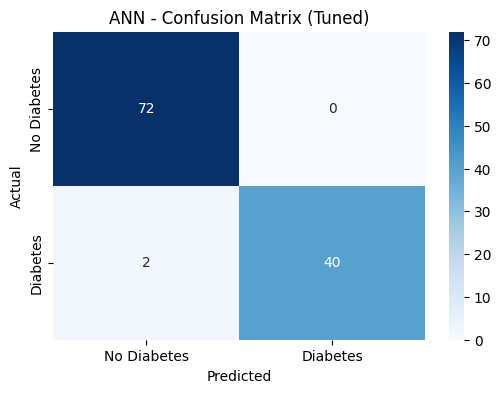

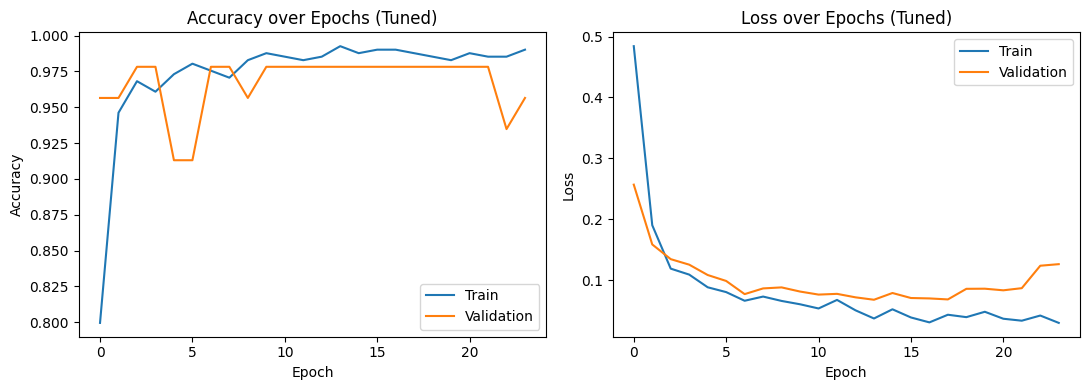

In [5]:
# 1. Install required libraries
!pip install opendatasets keras-tuner

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import opendatasets as od

# 2. Download Dataset from Kaggle
# You will be prompted for your Kaggle Username and API Key
dataset_url = "https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data"
od.download(dataset_url)

# 3. Load and Preprocess Data
df = pd.read_csv("breast-cancer-wisconsin-data/data.csv")

# Remove non-predictive ID and the empty artifact column
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Encode target labels to numeric: Malignant -> 1, Benign -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Define Features (X) and Target (y)
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPreprocessing complete. Training features: {X_train_scaled.shape[1]}")

# 4. Baseline ANN (No Tuning)
print("\n--- Training Baseline ANN ---")
baseline_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Baseline Evaluation
y_pred_baseline = (baseline_model.predict(X_test_scaled) >= 0.5).astype(int)
print("\n========== ANN (Baseline Results) ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_baseline, target_names=["Benign", "Malignant"]))

# 5. Hyperparameter Tuning with Keras Tuner
print("\n--- Starting Hyperparameter Search ---")

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # Tune the number of layers
    for i in range(hp.Int('num_layers', 1, 3)):
        # Tune number of units in each layer
        units = hp.Choice(f'units_{i}', [16, 32, 64, 128])
        model.add(layers.Dense(units, activation='relu'))

        # Tune Dropout rate
        dropout_rate = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate
    lr = hp.Choice('learning_rate', [1e-4, 1e-3, 5e-3])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,
    directory='tuning_results',
    project_name='breast_cancer_ann',
    overwrite=True
)

# Search for the best parameters
tuner.search(X_train_scaled, y_train, epochs=50, validation_split=0.1, verbose=0)

# 6. FINAL TUNED MODEL TRAINING (Displays Logs and Curves)
print("\n--- Training Best Tuned Model ---")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Construct the model with best hyperparameters
final_model = tuner.hypermodel.build(best_hps)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training the final model with verbose=1 to show epoch logs
final_history = final_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(final_history.history['accuracy'])}")

# 7. PRINT FINAL RESULTS AND VISUALIZATIONS
print("\n========== Best Hyperparameters Found ==========")
print(f"num_layers    : {best_hps.get('num_layers')}")
for i in range(best_hps.get('num_layers')):
    print(f"units_{i}      : {best_hps.get(f'units_{i}')}")
    print(f"dropout_{i}    : {best_hps.get(f'dropout_{i}')}")
print(f"learning_rate : {best_hps.get('learning_rate')}")

# Evaluate Final Model
y_pred_tuned_prob = final_model.predict(X_test_scaled).flatten()
y_pred_tuned = (y_pred_tuned_prob >= 0.5).astype(int)

print("\n========== ANN (With Tuning) ==========")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned, target_names=["Benign", "Malignant"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("ANN - Confusion Matrix (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot Accuracy and Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Accuracy Curve
ax1.plot(final_history.history['accuracy'], label='Train')
ax1.plot(final_history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (Tuned)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss Curve
ax2.plot(final_history.history['loss'], label='Train')
ax2.plot(final_history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (Tuned)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

Skipping, found downloaded files in "./breast-cancer-wisconsin-data" (use force=True to force download)

Preprocessing complete. Training features: 30


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8900 - loss: 0.4674 - val_accuracy: 0.9348 - val_loss: 0.3184
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9535 - loss: 0.2611 - val_accuracy: 0.9565 - val_loss: 0.1905
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9633 - loss: 0.1686 - val_accuracy: 0.9565 - val_loss: 0.1442
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9682 - loss: 0.1240 - val_accuracy: 0.9565 - val_loss: 0.1227
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9780 - loss: 0.0968 - val_accuracy: 0.9348 - val_loss: 0.1202
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.0798 - val_accuracy: 0.9348 - val_loss: 0.1126
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.0695 - val_accuracy: 0.9348 - val_loss: 0.1069
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.0619 - val_accuracy: 0.934

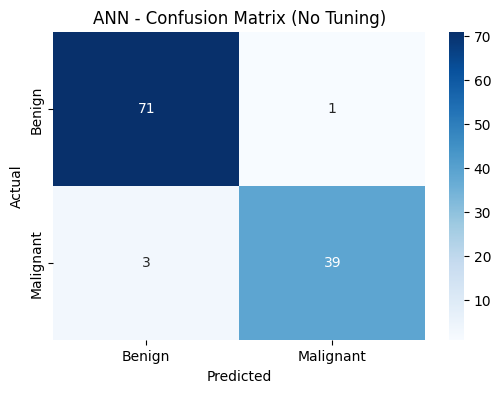

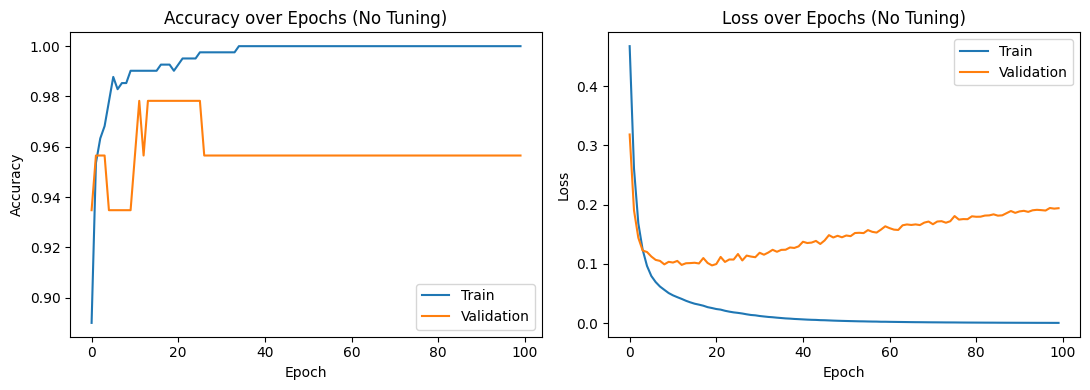

In [7]:
# 1. Install required libraries
!pip install opendatasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import opendatasets as od

# 2. Data Collection: Download and Load Data from Kaggle
# You will be prompted for your Kaggle Username and API Key
dataset_url = "https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data"
od.download(dataset_url)
df = pd.read_csv("breast-cancer-wisconsin-data/data.csv")

# 3. Data Preprocessing
# Remove non-predictive ID and the empty artifact column
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Encode target labels to numeric: Malignant -> 1, Benign -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Define Features (X) and Target (y)
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

# Train-Test Split (80% Training, 20% Testing, Stratified) [cite: 408, 409, 509-511]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling: Normalize inputs using StandardScaler [cite: 402, 411, 516-520]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPreprocessing complete. Training features: {X_train_scaled.shape[1]}")

# 4. Baseline ANN Model Configuration (Without Tuning)
# Architecture: Input(30) -> Dense(64, ReLU) -> Dense(32, ReLU) -> Dense(1, Sigmoid) [cite: 413, 521-527]
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

# Compile with default Adam optimizer (lr = 0.001) [cite: 414, 528-532]
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 5. Train Baseline Model
# Training for 100 epochs with a batch size of 32 [cite: 414, 535-541]
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# 6. Final Evaluation [cite: 415, 543-550]
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
print("\n========== ANN (No Tuning) ==========")
print(f"Accuracy: {acc * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benign", "Malignant"]))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("ANN - Confusion Matrix (No Tuning)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs (No Tuning)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs (No Tuning)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.tight_layout()
plt.show()